In [1]:
JUPYTER_NAME = "1-lens-simulation"

In [2]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as constants
from qiskit import transpile
from qiskit.circuit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator, Statevector, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer_encore.simulator import generate_aer_simulator
from qiskit_hamiltonian_simulation.time_independent.direct import (
    MomentumDomainEvolutionQuadratic,
    PositionDomainEvolutionQuadratic,
)
from qiskit_hamiltonian_simulation.time_independent.sample_based import (
    KineticEvolutionSampleBased,
    PotentialEvolutionSampleBased,
)
from qiskit_phase_propagator.sample_based import (
    QuadraticSignalSampleBasedPhasePropagator,
)
from qiskit_signals.helper_types import EncodingType
from qiskit_signals.quantum_axis import (
    AngularWavenumberAxis,
    MomentumAxis,
    PositionAxis,
)
from qiskit_signals.quantum_signal import GenericQuantumSignal, QuadraticQuantumSignal
from qiskit_signals.sample_based_signal import ArbitrarySignalForSampleBasedProtocol
from wave_optics_propagation.big_matrix_version import big_matrix_circ
from wave_optics_propagation.elements import (
    free_space_signal_generator,
    radius_of_convex_planar_lens_as_a_func_of_z,
    thin_lens_signal_generator,
    thin_transparent_plate_signal_generator,
)
from wave_optics_propagation.storage import save_circuit, save_results
from wave_optics_propagation.visualization import plot_wavefunction

In [3]:
AerSimulator().available_devices()

('CPU', 'GPU')

In [4]:
experiment_datetime = datetime.now()

---


### Initial parameters


In [5]:
# beam parameters
vacuum_wavelength = 1e-6  # 1 micron
beam_FWHM = 5e-3  # 5 mm

# lens parameters
focal_length = 200  # 200 mm
lens_diameter = 25e-3  # 25 mm
refractive_index = 1.3
lens_thickness = 0.001  # 1 mm

# free space propagation parameters
propagation_after_lens = 1.5 * focal_length  # 1.5 times focal length
propagation_after_lens = 1 * focal_length  # 1.5 times focal length

# simulation parameters
transverse_length = 0.10  # 10 cm, transverse simulation window
num_of_steps_after_lens = 5
lens_slices = 20
num_qubits = 7
max_delta = 0.03

### Constants


In [6]:
c = constants.c
# hbar = constants.hbar

### Derived parameters


In [7]:
k_0 = 2 * constants.pi / vacuum_wavelength

dimension = 2**num_qubits
delta_x = transverse_length / dimension

gaussian_mean = transverse_length / 2
gaussian_beam_waist = beam_FWHM / (np.sqrt(2 * np.log(2)))
gaussian_sigma = gaussian_beam_waist / np.sqrt(2)

vacuum_rayleigh_length = (np.pi * gaussian_beam_waist**2) / vacuum_wavelength


### Derived objects


In [8]:
lens_slice_positions = np.linspace(0, lens_thickness, lens_slices, endpoint=False)
lens_slice_thickness = lens_thickness / lens_slices

step_size_after_lens = propagation_after_lens / num_of_steps_after_lens

lens_lengths = [
    radius_of_convex_planar_lens_as_a_func_of_z(focal_length, z, lens_thickness)
    for z in lens_slice_positions
]
print(lens_slice_positions)
print(lens_lengths)

[0.0e+00 5.0e-05 1.0e-04 1.5e-04 2.0e-04 2.5e-04 3.0e-04 3.5e-04 4.0e-04
 4.5e-04 5.0e-04 5.5e-04 6.0e-04 6.5e-04 7.0e-04 7.5e-04 8.0e-04 8.5e-04
 9.0e-04 9.5e-04]
[np.float64(0.0), np.float64(0.14142134737679868), np.float64(0.19999997500926683), np.float64(0.24494892833636728), np.float64(0.2828426417741979), np.float64(0.31622766719259227), np.float64(0.3464100316190332), np.float64(0.3741655749817125), np.float64(0.39999980000643065), np.float64(0.4242638300669934), np.float64(0.4472133159859912), np.float64(0.4690412535195879), np.float64(0.4898975811311298), np.float64(0.5099015370654716), np.float64(0.5291497992057356), np.float64(0.5477220440204166), np.float64(0.5656848592628242), np.float64(0.5830945699528237), np.float64(0.599999324997391), np.float64(0.6164406682681426)]


### Approximations checks


In [9]:
assert (
    gaussian_beam_waist > 10 * vacuum_wavelength
)  # ensure paraxial approximation validity

### Axes


In [10]:
x_axis = PositionAxis(
    num_qubits=num_qubits, delta_x=delta_x, encoding=EncodingType.UNSIGNED
)
k_axis = AngularWavenumberAxis.from_position_axis(x_axis)
# p_axis = MomentumAxis.from_position_axis(x_axis, hbar=hbar)

### Initial beam profile


301416.96576396155


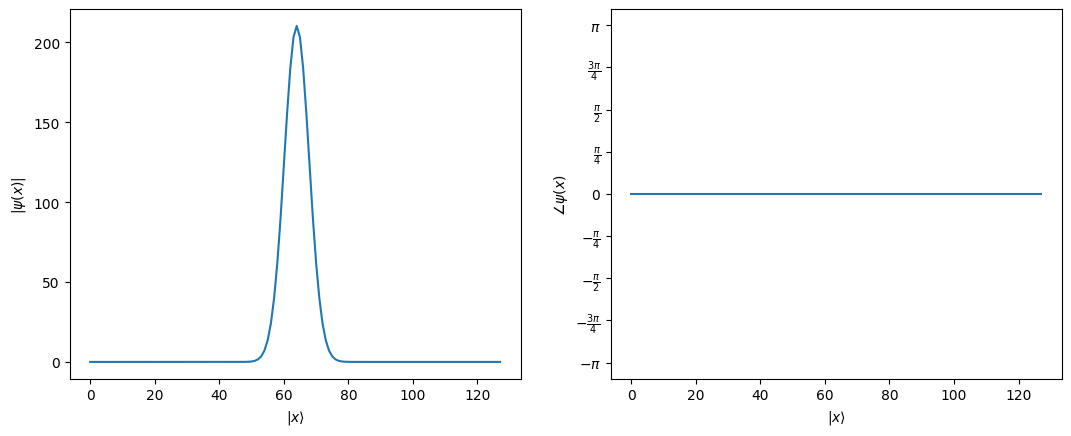

In [11]:
def psi_signal_function(x):
    norm_factor = 1 / (gaussian_sigma * (2 * constants.pi) ** 0.25)
    return norm_factor * np.exp(-(((x - gaussian_mean) / gaussian_beam_waist) ** 2))


# def psi_signal_function(x):
#     return np.where(
#         (x > 1 / 3) & (x < 2 / 3),
#         1,
#         0,
#     )


# def psi_signal_function(x):
#     signal = np.zeros(dimension)
#     middle = dimension // 2
#     signal[middle - 20 : middle - 15] = 1
#     signal[middle + 15 : middle + 20] = 1
#     return signal

# psi_flat = Statevector.from_label("+" * num_qubits)

psi = GenericQuantumSignal(x_axis, psi_signal_function)

print(np.linalg.norm(psi.data) ** 2)
plot_wavefunction(psi.data, normalize=False)

### Lens potentials


In [12]:
lens_lengths[0]

np.float64(0.0)

In [13]:
for i, lens_length in enumerate(lens_lengths):
    lens_signal = thin_transparent_plate_signal_generator(
        x_axis=x_axis,
        refractive_index=refractive_index,
        thickness=lens_slice_thickness,
        radius=lens_length,
        wavelength=vacuum_wavelength,
        scale_down=True,
    )
    # plot_wavefunction(lens_signal.data, normalize=False)

---


In [14]:
psi_reg = QuantumRegister(num_qubits, name=r"\psi")
phi_reg = QuantumRegister(num_qubits, name=r"\phi")
success_flag = ClassicalRegister(num_qubits, name="success_flag")
circuit = QuantumCircuit(psi_reg, phi_reg, success_flag)
# circuit = QuantumCircuit(psi_reg)

circuit.initialize(psi.data.tolist() / np.linalg.norm(psi.data), psi_reg)
# circuit.initialize(psi_flat, psi_reg)

circuit.save_statevector(label=f"step_{0}")  # type: ignore

### Lens
for i, lens_length in enumerate(lens_lengths):
    print(f"Doing lens slice {i + 1}/{lens_slices}")

    lens_signal = thin_transparent_plate_signal_generator(
        x_axis=x_axis,
        refractive_index=refractive_index,
        thickness=lens_slice_thickness,
        radius=lens_length,
        wavelength=vacuum_wavelength,
        scale_down=True,
    )
    sample_based_lens_signal = (
        ArbitrarySignalForSampleBasedProtocol.from_generic_signal(lens_signal)
    )

    if not np.isclose(np.std(sample_based_lens_signal.data), 0) and not np.isclose(
        np.std(sample_based_lens_signal.data), 2 * np.pi
    ):
        print(np.max(np.abs(sample_based_lens_signal.data)))
        print(np.sum(np.abs(sample_based_lens_signal.data) ** 2))
        # continue
        lens = QuadraticSignalSampleBasedPhasePropagator(
            signal=sample_based_lens_signal, max_delta=max_delta
        )
        print(f"had {lens.num_of_cycles} cycles")

        circuit.compose(
            lens,
            circuit.qubits,
            circuit.clbits,
            inplace=True,
        )

    else:
        print("Skipped the lens slice because it is a flat phase.")

    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=lens_slice_thickness / c,
        wavelength=vacuum_wavelength,
        c=constants.c,
    )
    propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    circuit.compose(
        big_matrix_circ(propagator),
        psi_reg,
        inplace=True,
    )
    circuit.save_statevector(label=f"step_lens_{i}")  # type: ignore

# circuit.save_statevector(label="after_lens")  # type: ignore

for i in range(num_of_steps_after_lens):
    print(f"Doing free space step {i + 1}/{num_of_steps_after_lens}")

    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=step_size_after_lens / c,
        wavelength=vacuum_wavelength,
        c=constants.c,
    )
    propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    circuit.compose(
        big_matrix_circ(propagator),
        psi_reg,
        inplace=True,
    )
    circuit.save_statevector(label=f"step_after_lens_{i + 1}")  # type: ignore

# circuit.save_statevector()  # type: ignore


Doing lens slice 1/20
6.283185307179565
39.47841760435716
Using big matrix state initializer.
direct de-initializer
Using big matrix state de-initializer.
had 210 cycles
Doing lens slice 2/20
Skipped the lens slice because it is a flat phase.
Doing lens slice 3/20
Skipped the lens slice because it is a flat phase.
Doing lens slice 4/20
Skipped the lens slice because it is a flat phase.
Doing lens slice 5/20
Skipped the lens slice because it is a flat phase.
Doing lens slice 6/20
Skipped the lens slice because it is a flat phase.
Doing lens slice 7/20
Skipped the lens slice because it is a flat phase.
Doing lens slice 8/20
Skipped the lens slice because it is a flat phase.
Doing lens slice 9/20
Skipped the lens slice because it is a flat phase.
Doing lens slice 10/20
Skipped the lens slice because it is a flat phase.
Doing lens slice 11/20
Skipped the lens slice because it is a flat phase.
Doing lens slice 12/20
Skipped the lens slice because it is a flat phase.
Doing lens slice 13/20
S

In [15]:
# circuit.draw("mpl")

In [16]:
save_circuit(
    circuit, "original_circuit", experiment_datetime, wrapper_folder=JUPYTER_NAME
)

In [17]:
simulator = generate_aer_simulator(force_gpu=True)
transpiled_circuit = transpile(circuit)

In [18]:
# transpiled_circuit.draw("mpl")

In [19]:
# job = simulator.run(transpiled_circuit, shots=1)
job = simulator.run(circuit, shots=1)

In [20]:
result = job.result()

In [21]:
# save_results(result, "raw_result", experiment_datetime, wrapper_folder=JUPYTER_NAME)

In [22]:
data = result.data()
counts = result.get_counts().int_outcomes()
assert counts[0] == 1

In [23]:
# def process_statevector(statevector):
#     return statevector
def process_statevector(statevector):
    """Process the statevector to extract position probabilities."""
    n = statevector.num_qubits
    rho = partial_trace(statevector, np.arange(int(n // 2), n).tolist())
    reduced_state = rho.to_statevector()

    return reduced_state


initial_statevector = process_statevector(data[f"step_{0}"])

lens_statevectors = [
    process_statevector(data[f"step_lens_{i}"]) if f"step_lens_{i}" in data else None
    for i in range(lens_slices)
]
after_lens_statevectors = [
    process_statevector(data[f"step_after_lens_{i + 1}"])
    if f"step_after_lens_{i + 1}" in data
    else None
    for i in range(num_of_steps_after_lens)
]

Plotting initial state


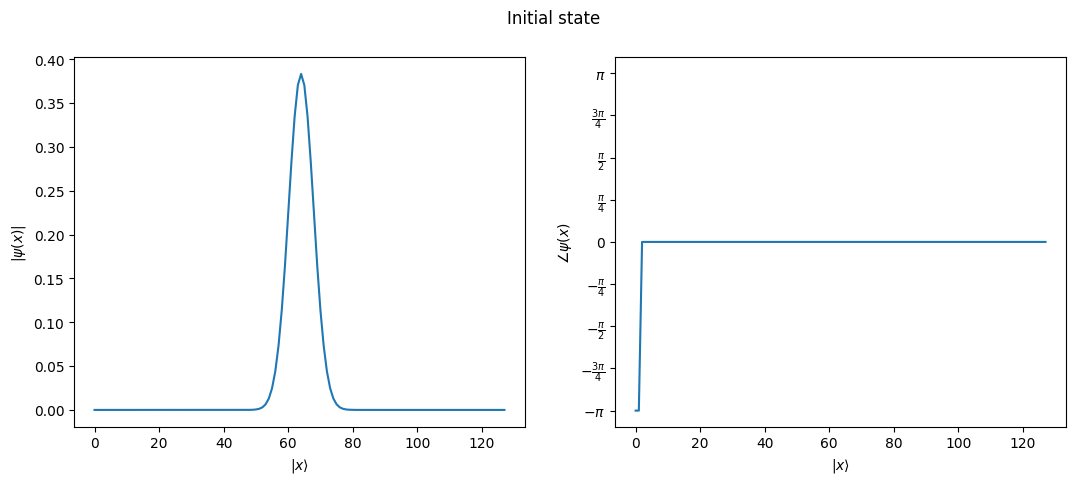

Plotting lens slice 1/20


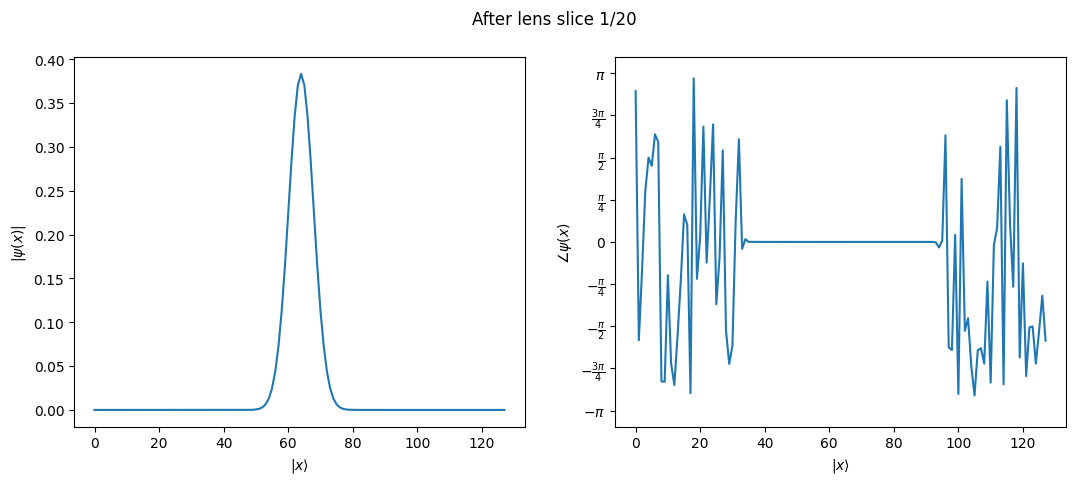

Plotting lens slice 2/20


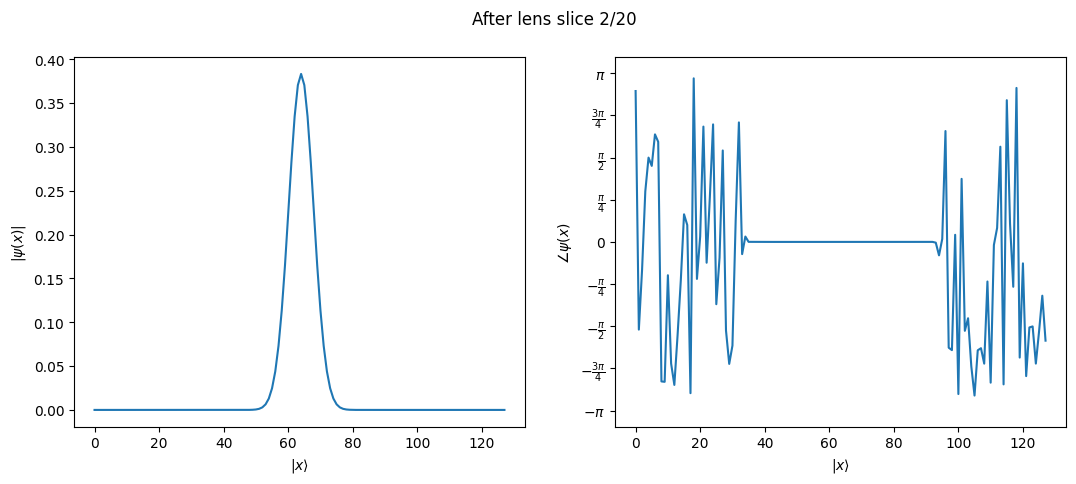

Plotting lens slice 3/20


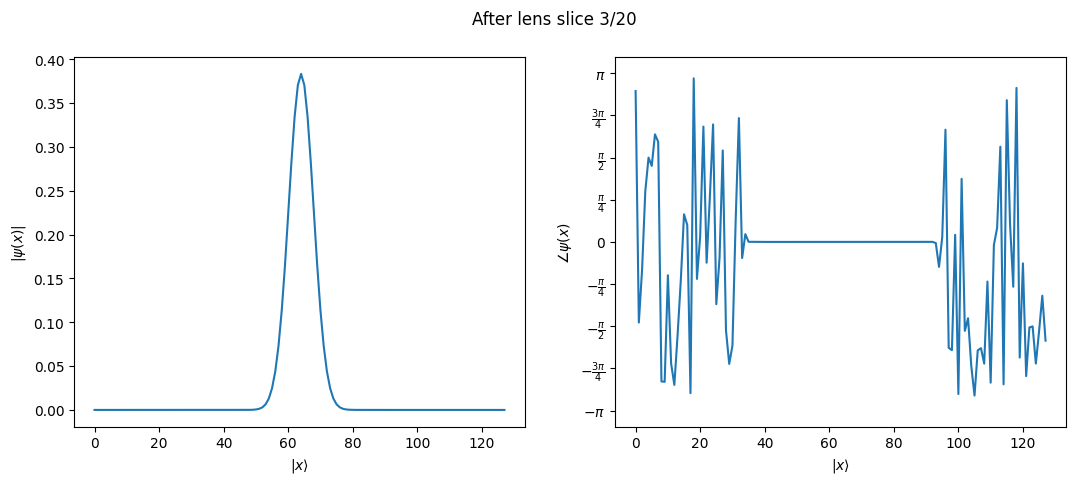

Plotting lens slice 4/20


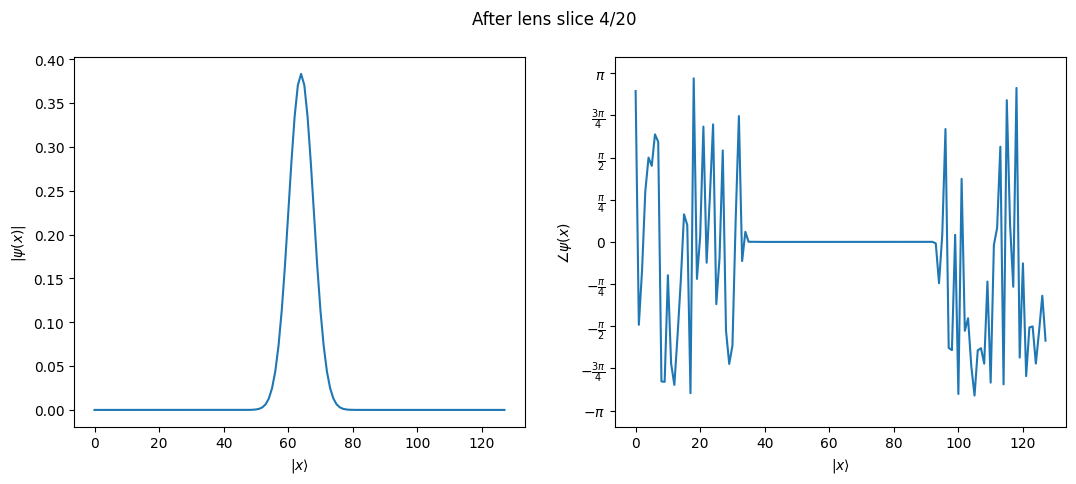

Plotting lens slice 5/20


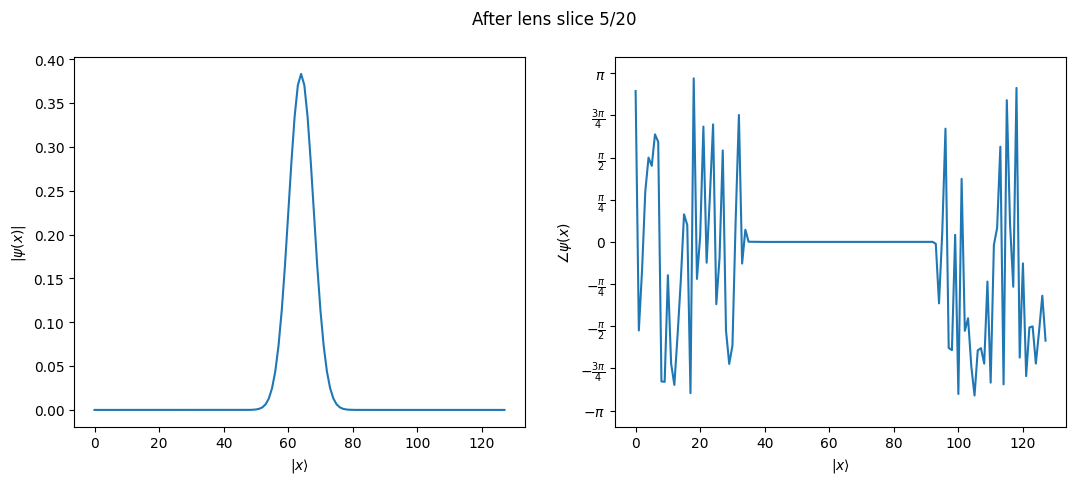

Plotting lens slice 6/20


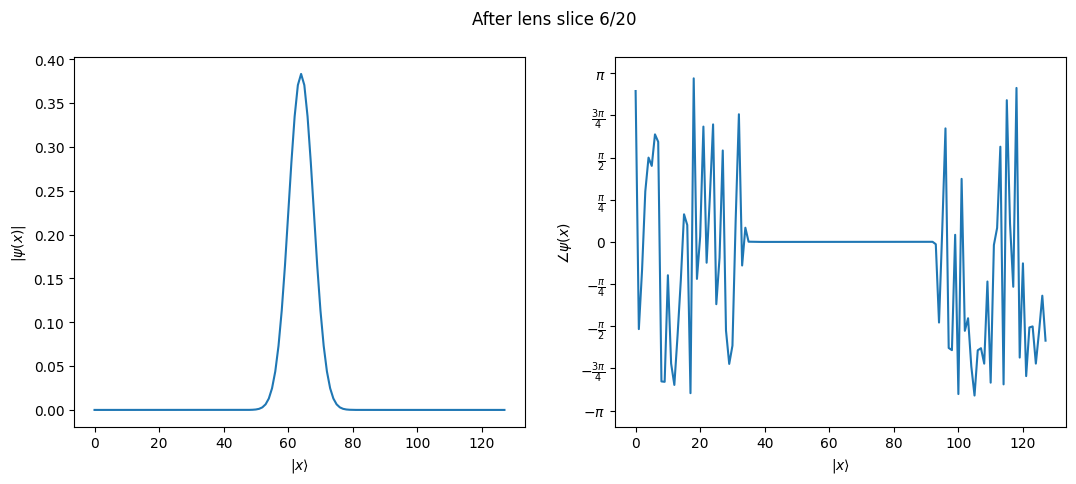

Plotting lens slice 7/20


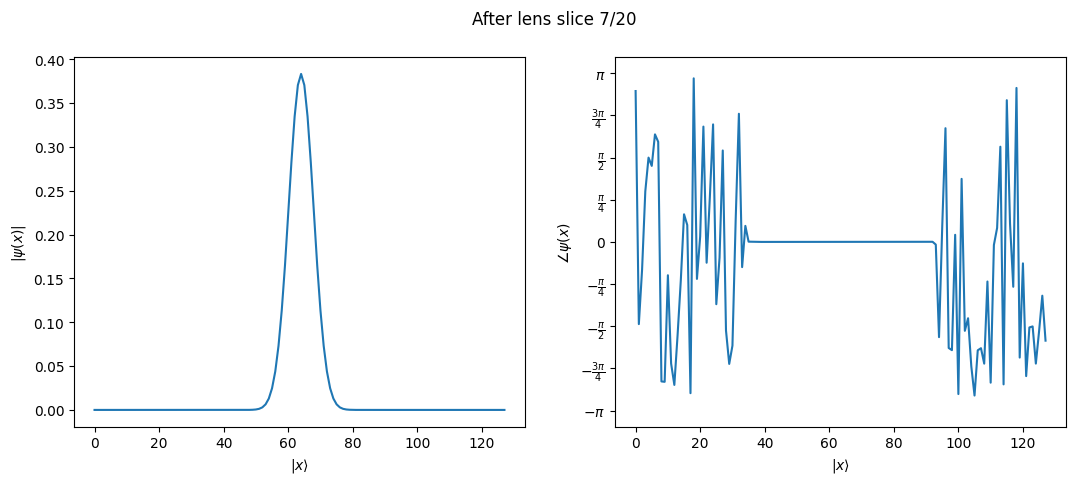

Plotting lens slice 8/20


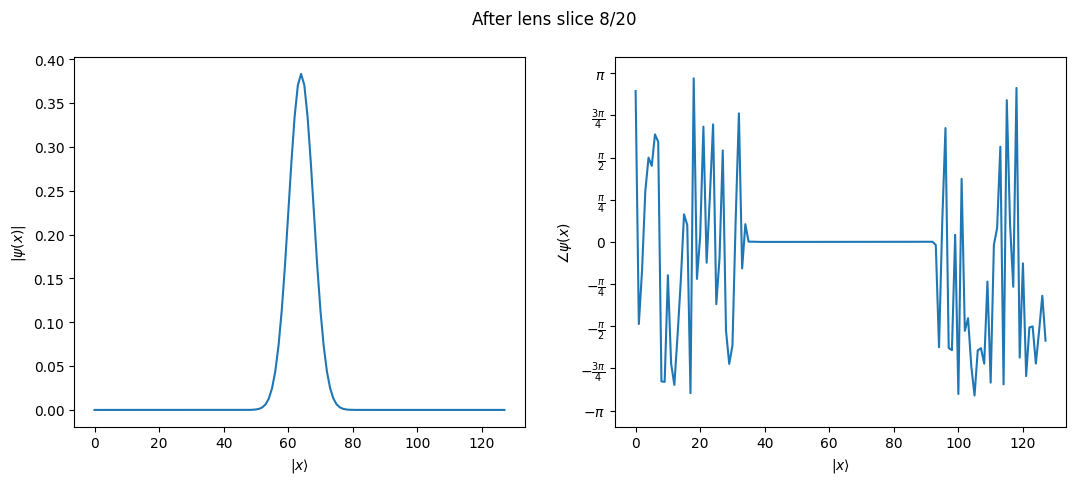

Plotting lens slice 9/20


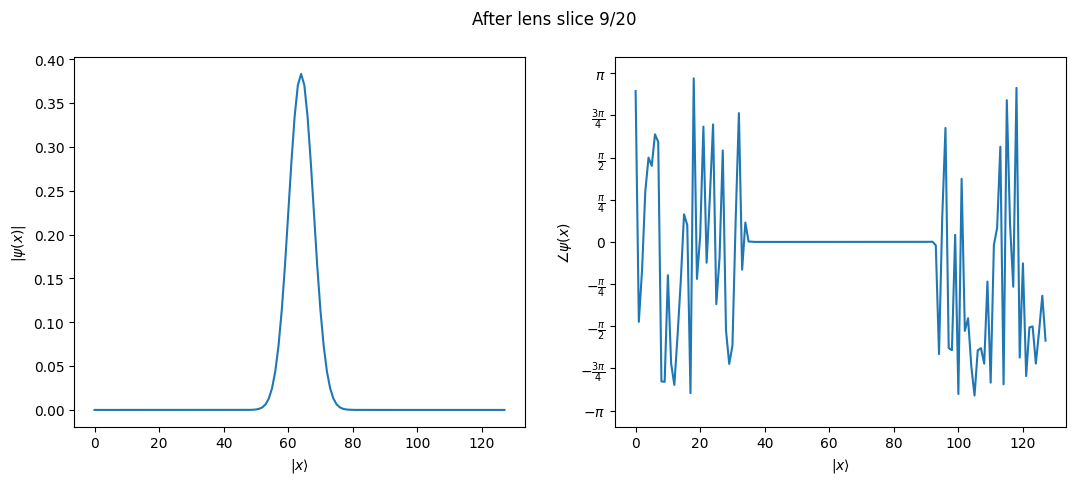

Plotting lens slice 10/20


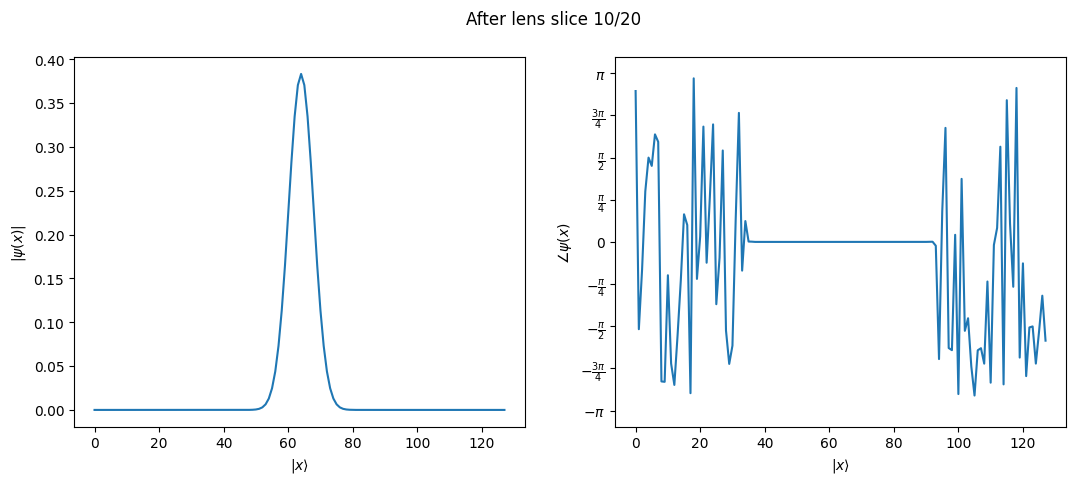

Plotting lens slice 11/20


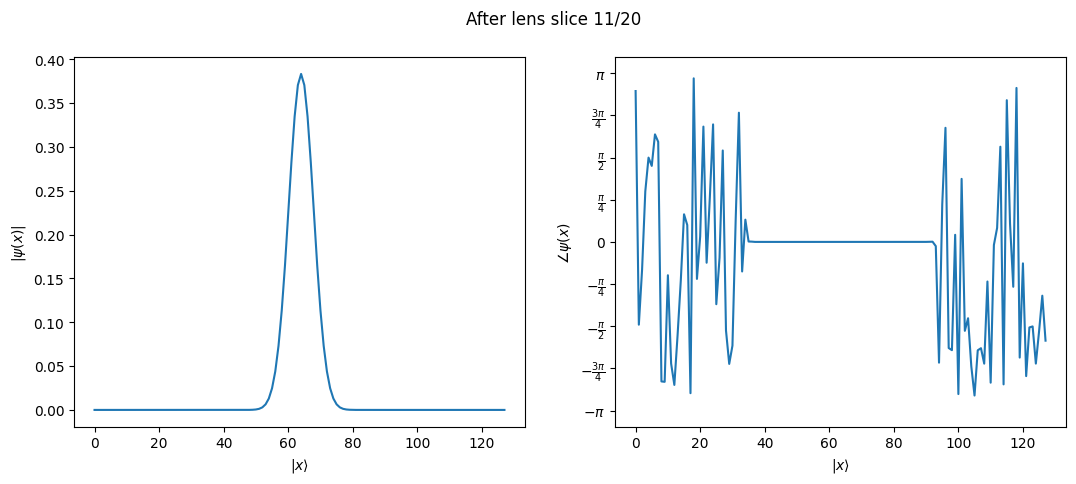

Plotting lens slice 12/20


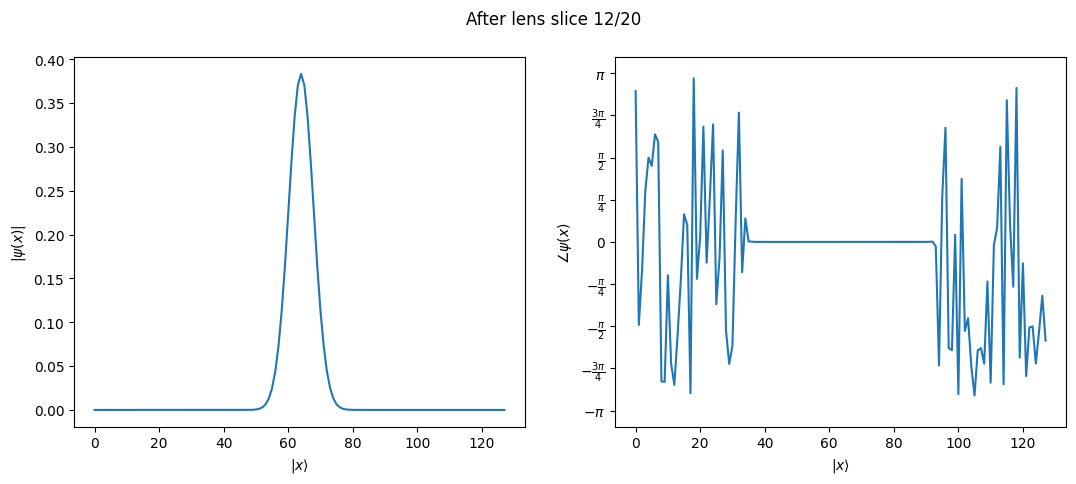

Plotting lens slice 13/20


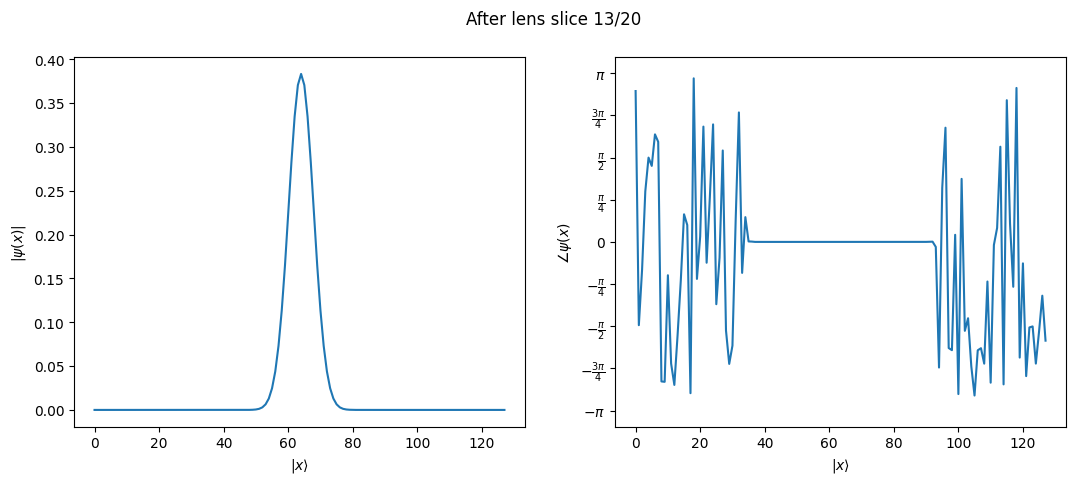

Plotting lens slice 14/20


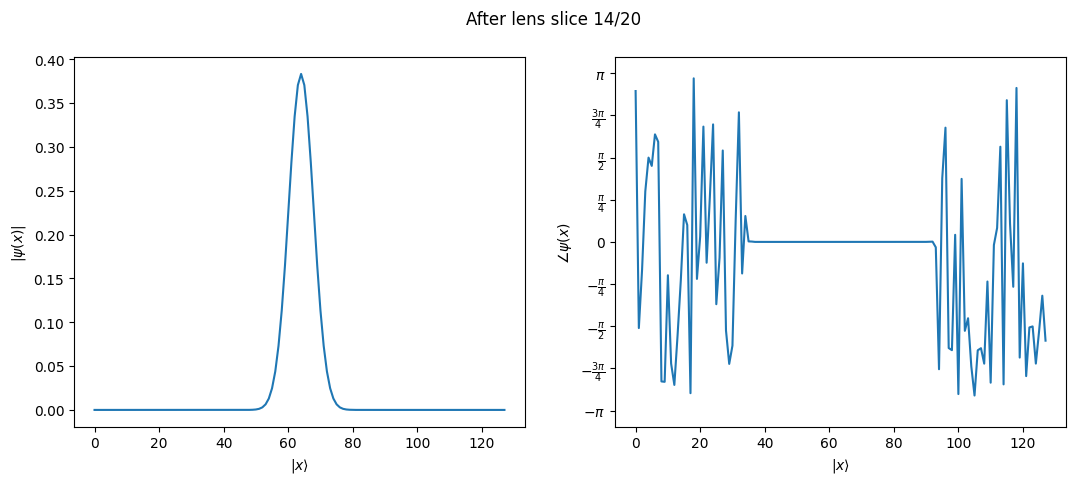

Plotting lens slice 15/20


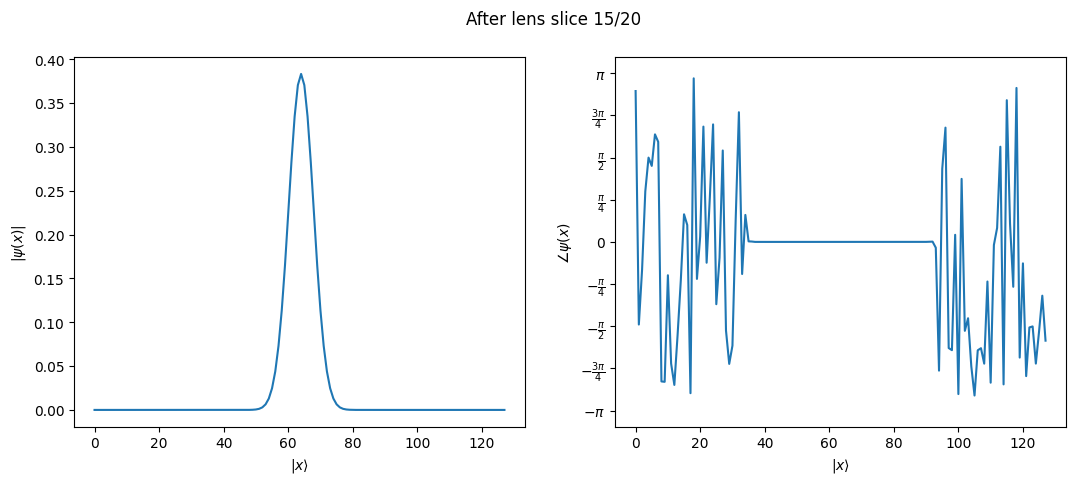

Plotting lens slice 16/20


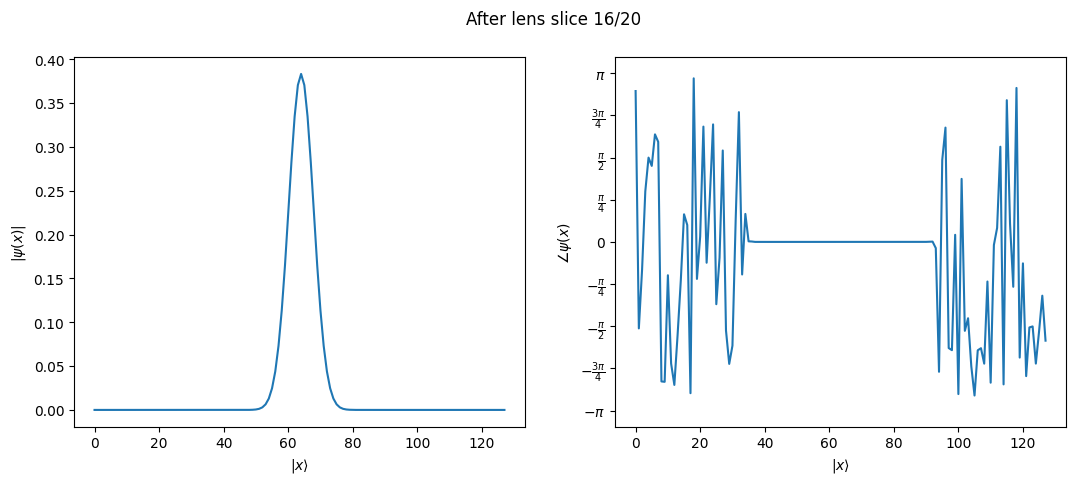

Plotting lens slice 17/20


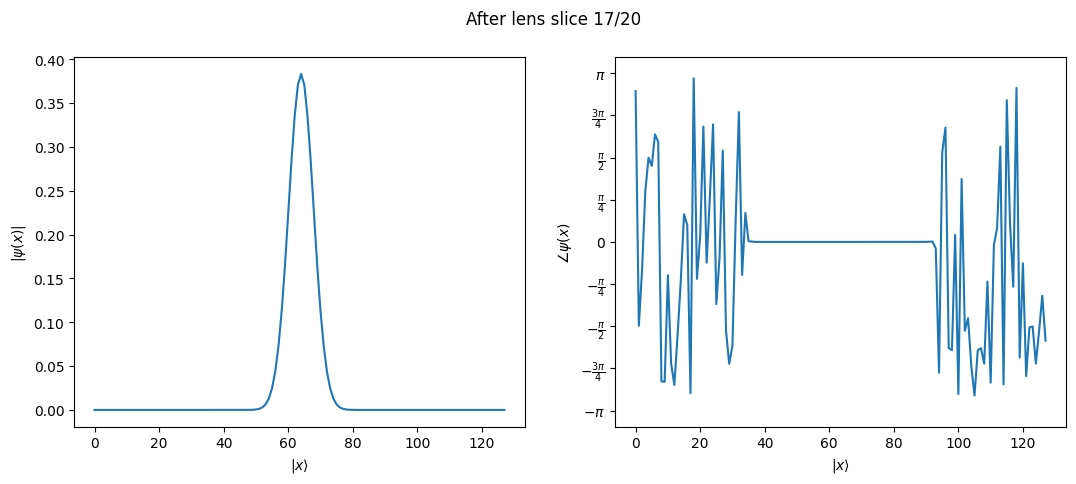

Plotting lens slice 18/20


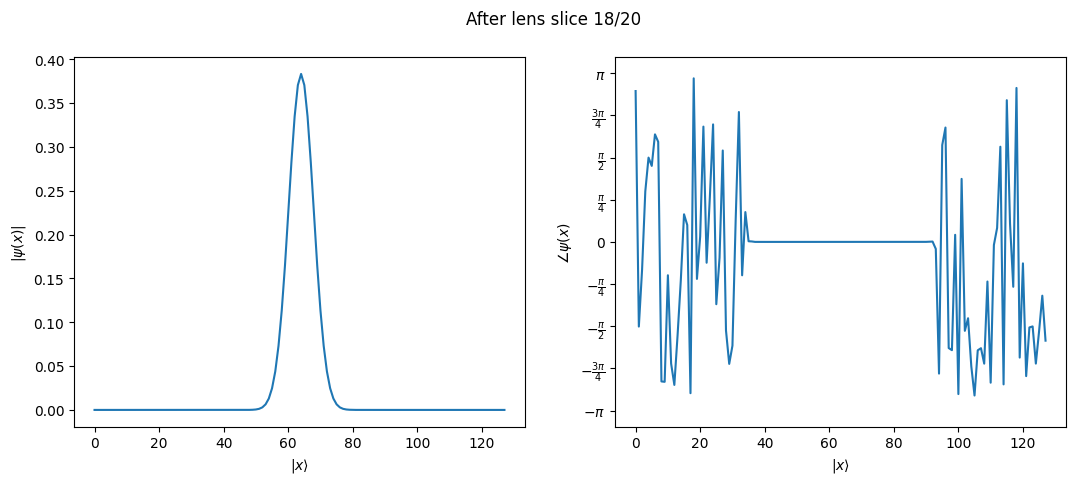

Plotting lens slice 19/20


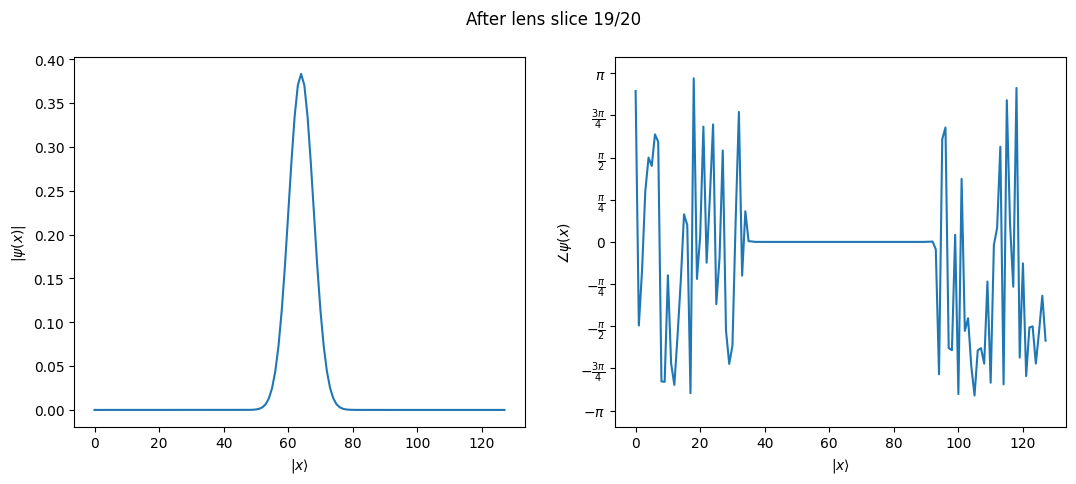

Plotting lens slice 20/20


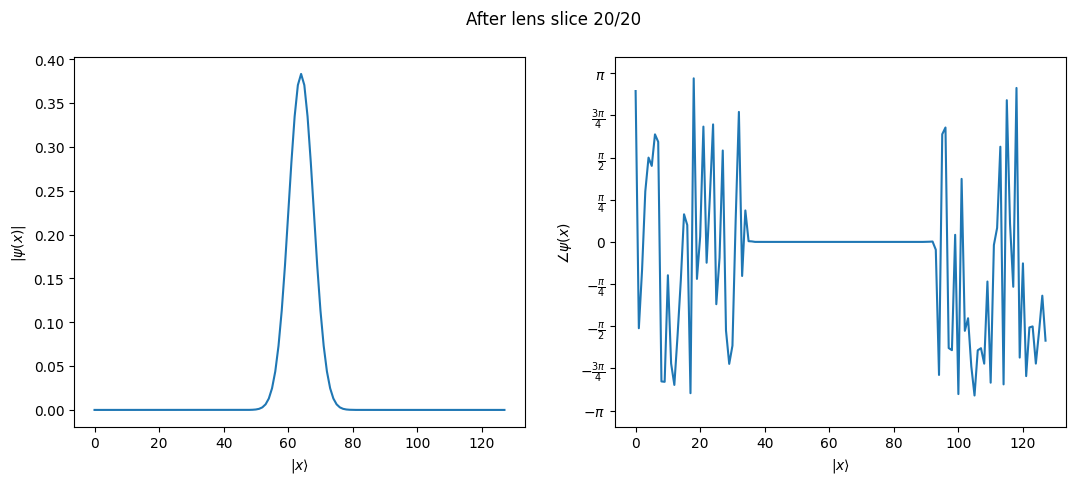

Plotting free space step 1/5


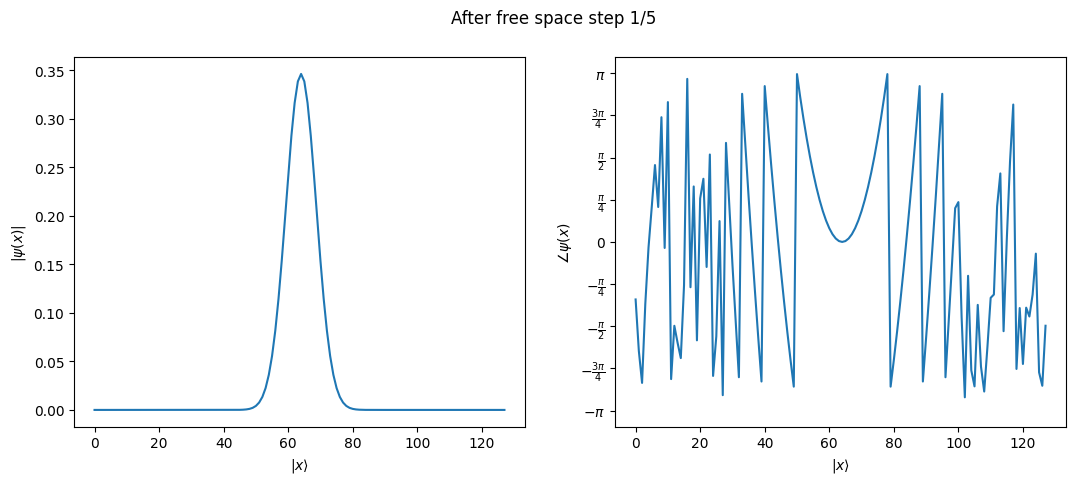

Plotting free space step 2/5


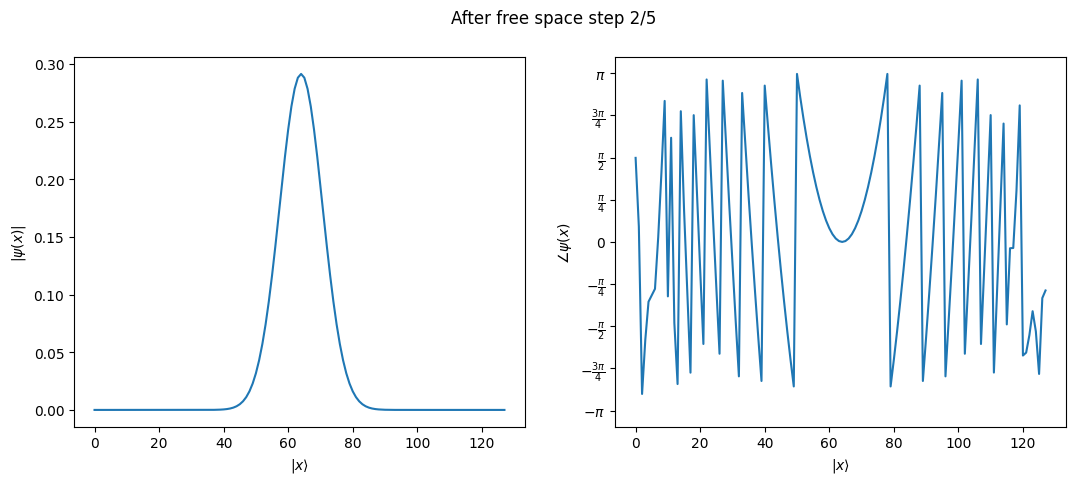

Plotting free space step 3/5


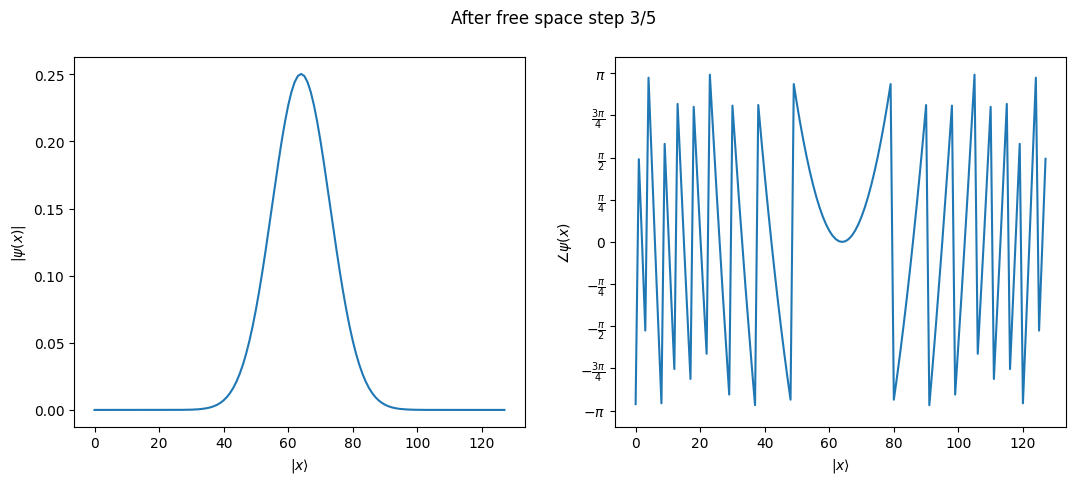

Plotting free space step 4/5


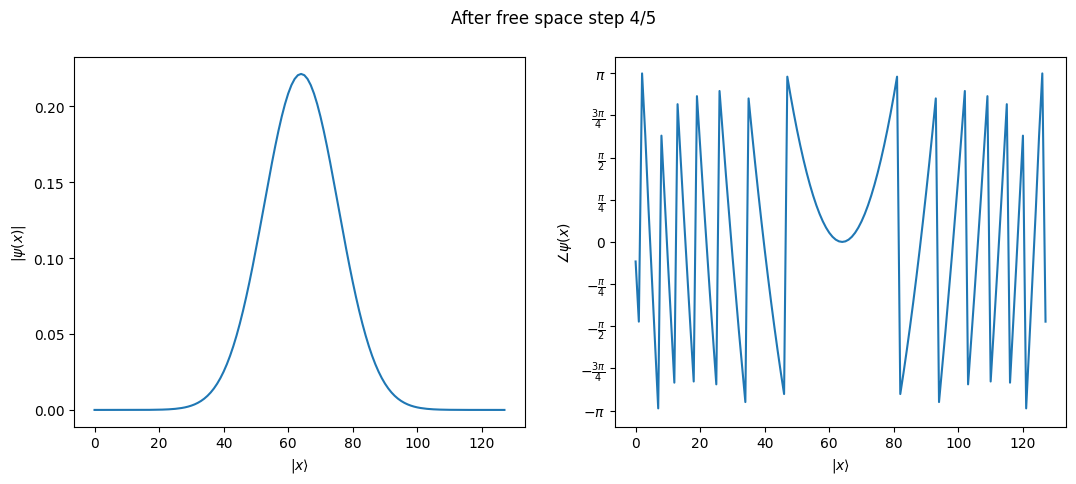

Plotting free space step 5/5


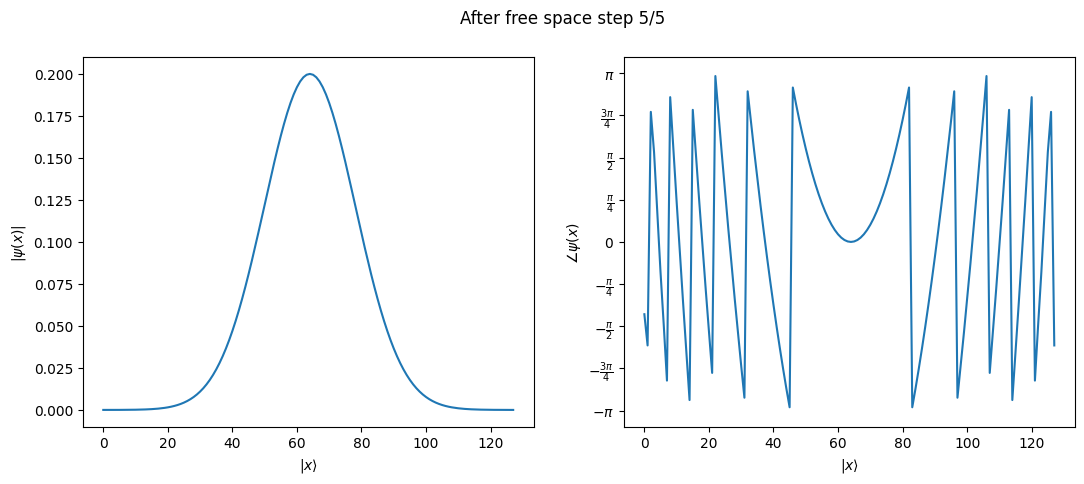

In [24]:
print("Plotting initial state")
plot_wavefunction(initial_statevector, plot_size_scale=1, normalize=True)
plt.suptitle("Initial state")
plt.show()

for i, statevector in enumerate(lens_statevectors):
    if statevector is None:
        continue
    print(f"Plotting lens slice {i + 1}/{lens_slices}")
    plot_wavefunction(statevector, plot_size_scale=1, normalize=True)
    plt.suptitle(f"After lens slice {i + 1}/{lens_slices}")
    plt.show()

for i, statevector in enumerate(after_lens_statevectors):
    if statevector is None:
        continue
    print(f"Plotting free space step {i + 1}/{num_of_steps_after_lens}")
    plot_wavefunction(statevector, plot_size_scale=1, normalize=True)
    plt.suptitle(f"After free space step {i + 1}/{num_of_steps_after_lens}")
    plt.show()

In [25]:
# final_state = process_statevector(result.get_statevector())

In [26]:
# plot_wavefunction(final_state, plot_size_scale=1, normalize=True)